# Autofit tool for aligning data with the modes

`pyMMF.tools.autofit` allows for finding the transformation to center the fiber axis and the zoom to fit the simulated modes.

In [2]:
import matplotlib.pyplot as plt
import numpy as np



import os, sys
print(os.path.abspath('../..'))
os.chdir(os.path.abspath('../..'))
# sys.path.insert(0, os.path.abspath('..'))


import pyMMF
print(pyMMF.__path__)
from pyMMF.functions import colorize
from pyMMF.tools.autofit import autofit

/home/spopoff/mycore
['/home/spopoff/mycore/dev/pyMMF/pyMMF']


## 1. Fiber parameters

In [3]:
NA = 0.2
radius = 25 # in microns
areaSize = 3.*radius # calculate the field on an area larger than the diameter of the fiber
n_points_modes = 256 # resolution of the window2
n1 = 1.45 # index of refraction at r=0 (maximum)
wl = 1.55 # wavelength in microns
curvature = None
k0 = 2.*np.pi/wl

r_max = 3.2*radius
npoints_search = 2**8
dh = 2*radius/npoints_search

# solver parameters
solver_options = {
    'degenerate_mode': 'exp', # 'eig' or 'prop'
    'min_radius_bc': 1.5,   # min large radial boundary condition
    'N_beta_coarse': 1_000, # number of steps of the initial coarse scan
    'change_bc_radius_step': 0.95, #change of the large radial boundary condition if fails 
    'dh': dh,               # radial resolution during the computation
    'r_max': r_max,         # max radius to calculate (and first try for large radial boundary condition)
}

## 2. Compute the mode with radial solver

In [4]:
profile = pyMMF.IndexProfile(
    npoints = n_points_modes, 
    areaSize = areaSize
)
profile.initParabolicGRIN(n1=n1, a=radius, NA=NA)

solver = pyMMF.propagationModeSolver()
solver.setIndexProfile(profile)
solver.setWL(wl)


modes = solver.solve(solver='radial',
                    curvature = curvature,
                    options = solver_options
                    )


2025-10-14 16:13:12,241 - pyMMF.core [DEBUG  ]  Debug mode ON.
2025-10-14 16:13:12,242 - pyMMF.solv [INFO   ]  Searching for modes with beta_min=5.821637357564584, beta_max=5.877818513168


2025-10-14 16:13:12,263 - pyMMF.solv [INFO   ]  Found 5 radial mode(s) for m=0
2025-10-14 16:13:12,263 - pyMMF.solv [INFO   ]  Searching propagation constant for |l| = 1
2025-10-14 16:13:12,265 - pyMMF.solv [ERROR  ]  Field limit 1.0 at the founded beta=0.05066217542815342 is greater than field_limit_tol=0.001
2025-10-14 16:13:12,266 - pyMMF.solv [WARNING]  Boundary condition could not be met.
2025-10-14 16:13:12,266 - pyMMF.solv [WARNING]  Retrying by changing r_max to 3.04a
2025-10-14 16:13:12,268 - pyMMF.solv [ERROR  ]  Field limit 1.0 at the founded beta=0.05066217542815342 is greater than field_limit_tol=0.001
2025-10-14 16:13:12,269 - pyMMF.solv [WARNING]  Boundary condition could not be met.
2025-10-14 16:13:12,269 - pyMMF.solv [WARNING]  Retrying by changing r_max to 2.89a
2025-10-14 16:13:12,271 - pyMMF.solv [ERROR  ]  Field limit 1.0 at the founded beta=0.05066217542815342 is greater than field_limit_tol=0.001
2025-10-14 16:13:12,272 - pyMMF.solv [WARNING]  Boundary condition

## 3. Simulating the shift/zoom of the data by applying a transformation of the modes

In [ ]:
M0 = modes.getModeMatrix()

af = autofit(modes)

# Use explicit params (list)
params = [1.15, (-3., 1.), (10., 5.)]
M1 = af.transform(M0, params=params)

In [ ]:
N = modes.indexProfile.npoints
M0 = modes.getModeMatrix()

TM_mode_basis = modes.getPropagationMatrix(1e4) # propagation of 1 cm
TM_0 = M0 @ TM_mode_basis @ M0.conj().T


TM_misaligned = af.getTransformationMatrix(params=params, n_points=N)
mean_I0 = np.mean(np.abs(M0)**2, axis=1).reshape((N, N))
mean_I1 = np.mean(np.abs(M1)**2, axis=1).reshape((N, N))

plt.figure(figsize=(12,7))
plt.subplot(1,2,1)
plt.imshow(mean_I0, cmap='hot', interpolation='nearest')
plt.axis('off')
plt.title('Mean Intensity of computed modes')
plt.subplot(1,2,2)
plt.imshow(mean_I1, cmap='hot', interpolation='nearest')
plt.axis('off')
plt.title('Mean Intensity of simulated data')
plt.show()

## 4. Autofit to find the transformation to recenter/rezoom the data

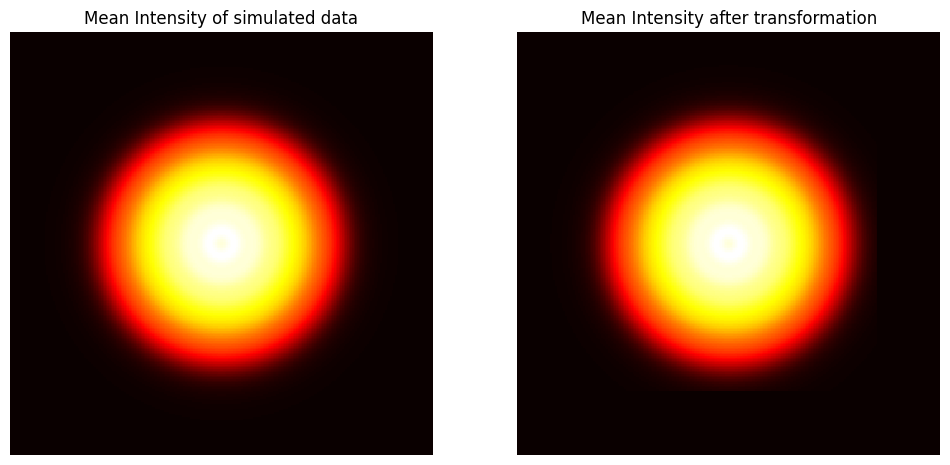

In [9]:


fit = autofit(modes)
fit.fit_to_data(mean_I1)                            # stores params
I_aligned = fit.transform(mean_I1)


plt.figure(figsize=(12,7))
plt.subplot(1,2,1)
plt.imshow(mean_I0, cmap='hot', interpolation='nearest')
plt.axis('off')
plt.title('Mean Intensity of simulated data')
plt.subplot(1,2,2)
plt.imshow(I_aligned, cmap='hot', interpolation='nearest')
plt.axis('off')
plt.title('Mean Intensity after transformation')

M1_aligned = fit.transform(M1)

Computation of the fidelity

In [10]:
fidelity_before = np.real(np.trace(M0.conj().T @ M1) / np.sqrt(np.trace(M0.conj().T @ M0) * np.trace(M1.conj().T @ M1)))    
fidelity_after = np.real(np.trace(M0.conj().T @ M1_aligned) / np.sqrt(np.trace(M0.conj().T @ M0) * np.trace(M1_aligned.conj().T @ M1_aligned)))

print(f"Mode fidelity before: {fidelity_before:.6f}, after: {fidelity_after:.6f}")

Mode fidelity before: 0.009801, after: 0.997804
